In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


importing the data set

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

checking the directories

In [ ]:
import os
print(os.listdir('/content/dataset'))
print(os.listdir('/content/dataset/dataset'))

['dataset']
['Potato_Potassium', 'Tomato_Phosphorus', 'Potato_Healthy', 'Potato_Phosphorus', 'Potato_Water_Stress', 'Potato_Nitrogen', 'Tomato_Water_Stress', 'Tomato_Nitrogen', 'Tomato_Healthy', 'Tomato_Potassium']


importing the libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Pre-Processing the data set

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_data = datagen.flow_from_directory(
    '/content/dataset/dataset',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/dataset/dataset',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(train_data.class_indices)

Found 8000 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.
{'Potato_Healthy': 0, 'Potato_Nitrogen': 1, 'Potato_Phosphorus': 2, 'Potato_Potassium': 3, 'Potato_Water_Stress': 4, 'Tomato_Healthy': 5, 'Tomato_Nitrogen': 6, 'Tomato_Phosphorus': 7, 'Tomato_Potassium': 8, 'Tomato_Water_Stress': 9}


building the model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Compiling the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

training model-Phase 1

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 211s 759ms/step - accuracy: 0.5616 - loss: 1.3624 - val_accuracy: 0.8080 - val_loss: 0.5569
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 686ms/step - accuracy: 0.7789 - loss: 0.6402 - val_accuracy: 0.8370 - val_loss: 0.4515
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 685ms/step - accuracy: 0.8129 - loss: 0.5209 - val_accuracy: 0.8530 - val_loss: 0.4037
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 170s 682ms/step - accuracy: 0.8406 - loss: 0.4475 - val_accuracy: 0.8585 - val_loss: 0.3717
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 169s 677ms/step - accuracy: 0.8553 - loss: 0.3913 - val_accuracy: 0.8630 - val_loss: 0.3669
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 178s 712ms/step - accuracy: 0.8708 - loss: 0.3608 - val_accuracy: 0.8600 - val_loss: 0.3639
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 169s 676ms/step - accuracy: 0.8774 - loss: 0.3351 - val_accuracy: 0.8650 - val_loss: 0.3366
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 170s 679ms/step - accuracy: 0.8821 -

Fine Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 707ms/step - accuracy: 0.7977 - loss: 0.5585 - val_accuracy: 0.8535 - val_loss: 0.4733
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 166s 663ms/step - accuracy: 0.8554 - loss: 0.4065 - val_accuracy: 0.8670 - val_loss: 0.4627
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 684ms/step - accuracy: 0.8717 - loss: 0.3530 - val_accuracy: 0.8745 - val_loss: 0.4245
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 168s 672ms/step - accuracy: 0.8856 - loss: 0.3120 - val_accuracy: 0.8725 - val_loss: 0.4077
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 167s 669ms/step - accuracy: 0.8955 - loss: 0.2756 - val_accuracy: 0.8740 - val_loss: 0.4046
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 168s 672ms/step - accuracy: 0.9036 - loss: 0.2602 - val_accuracy: 0.8800 - val_loss: 0.3661
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 168s 670ms/step - accuracy: 0.9097 - loss: 0.2399 - val_accuracy: 0.8855 - val_loss: 0.3487
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 169s 676ms/step - accuracy: 0.9160 -

Checking Accuracy

In [ ]:
model.evaluate(val_data)

63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - accuracy: 0.8910 - loss: 0.3291


[0.3290828466415405, 0.890999972820282]

Plot the accuracy graph

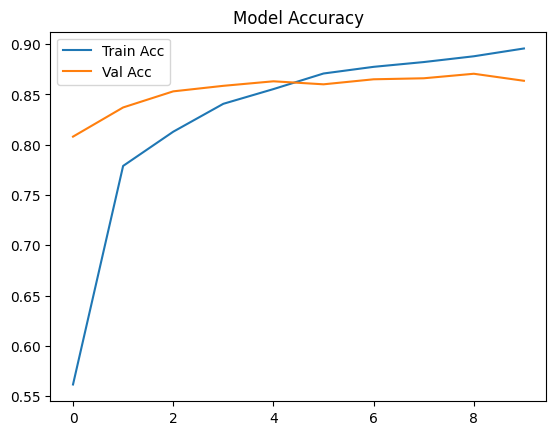

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

saving the model

In [ ]:
model.save('final_model.keras')

Conversion to TF lite model

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('final_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp8bzmfeiy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132494032340560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032343632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032346320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032345936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032344784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032346512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032344976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032347088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032346704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132494032344592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1324940323432

checking the TF-lite Accuracy

In [ ]:
from google.colab import files
files.download('final_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(model_path='final_model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])

Input dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 1  # 🔥 IMPORTANT

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data = datagen.flow_from_directory(
    '/content/dataset/dataset',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 2000 images belonging to 10 classes.


Tf lite Accuracy

In [ ]:
correct = 0
total = val_data.samples

for i in range(total):
    img, label = val_data[i]

    true_label = np.argmax(label)

    interpreter.set_tensor(input_details[0]['index'], img.astype(np.float32))
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output)

    if pred == true_label:
        correct += 1

accuracy = correct / total
print("✅ TFLite Accuracy:", accuracy)

✅ TFLite Accuracy: 0.8885


Quick Accuracy

In [ ]:
max_samples = 500
correct = 0
total = 0

for i in range(max_samples):
    img, label = val_data[i]

    true_label = np.argmax(label)

    interpreter.set_tensor(input_details[0]['index'], img.astype(np.float32))
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output)

    if pred == true_label:
        correct += 1

    total += 1

print("Quick Accuracy:", correct / total)

Quick Accuracy: 0.664


Sample image testing

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.jpg.jpg to test.jpg.jpg


In [ ]:
import tensorflow as tf
import numpy as np
import cv2

interpreter = tf.lite.Interpreter(model_path='final_model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
classes = [
    'Potato_Healthy',
    'Potato_Nitrogen',
    'Potato_Phosphorus',
    'Potato_Potassium',
    'Potato_Water_Stress',
    'Tomato_Healthy',
    'Tomato_Nitrogen',
    'Tomato_Phosphorus',
    'Tomato_Potassium',
    'Tomato_Water_Stress'
]

In [ ]:
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224,224))
img_normalized = img_resized / 255.0
img_input = np.expand_dims(img_normalized, axis=0).astype(np.float32)

In [ ]:
interpreter.set_tensor(input_details[0]['index'], img_input)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])

pred_index = np.argmax(output)
confidence = np.max(output)

predicted_class = classes[pred_index]

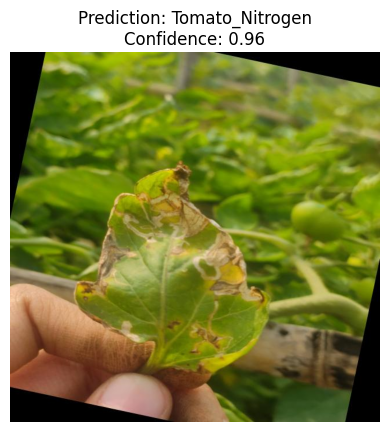

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

In [ ]:
print(f"✅ Model Prediction: {predicted_class}")
print(f"🔍 Confidence Level: {confidence:.2f}")

✅ Model Prediction: Tomato_Nitrogen
🔍 Confidence Level: 0.96


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_model.tflite to final_model.tflite


In [ ]:
!pip install opencv-python

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="final_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input dtype:", input_details[0]['dtype'])

Input shape: [  1 224 224   3]
Input dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
classes = [
'Potato_Healthy',
'Potato_Nitrogen',
'Potato_Phosphorus',
'Potato_Potassium',
'Potato_Water_Stress',
'Tomato_Healthy',
'Tomato_Nitrogen',
'Tomato_Phosphorus',
'Tomato_Potassium',
'Tomato_Water_Stress'
]

In [ ]:
uploaded = files.upload()

Saving images.jpg to images (5).jpg


In [ ]:
import cv2
import numpy as np

def predict_image(image_path):
    img = cv2.imread(image_path)
    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {image_path}. Please check the path.")
        return

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])[0]

    pred_index = np.argmax(output)
    confidence = output[pred_index]

    print("Prediction:", classes[pred_index])
    print("Confidence:", float(confidence))

# Example
predict_image(list(uploaded.keys())[0])

Prediction: Potato_Water_Stress
Confidence: 0.36672696471214294


### Testing with Multiple Images

In [ ]:
from google.colab import files

print("Upload multiple images:")
multi_uploaded_files = files.upload()

Upload multiple images:


Saving images (4).jpg to images (4) (1).jpg
Saving images (3).jpg to images (3) (1).jpg
Saving images (2).jpg to images (2) (1).jpg
Saving images (1).jpg to images (1) (1).jpg



Processing image: images (4) (1).jpg
Prediction: Potato_Phosphorus
Confidence: 0.5508679747581482


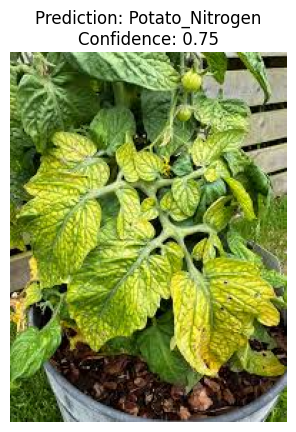


Processing image: images (3) (1).jpg
Prediction: Tomato_Phosphorus
Confidence: 0.40339869260787964


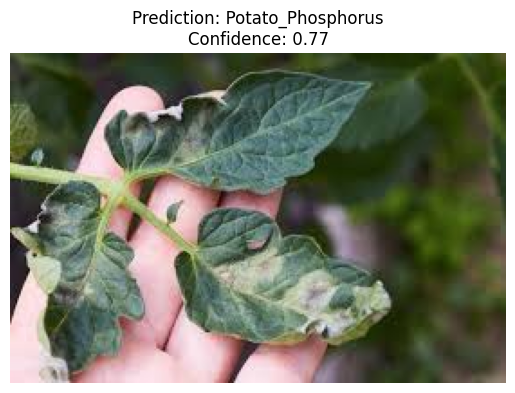


Processing image: images (2) (1).jpg
Prediction: Tomato_Phosphorus
Confidence: 0.9983918070793152


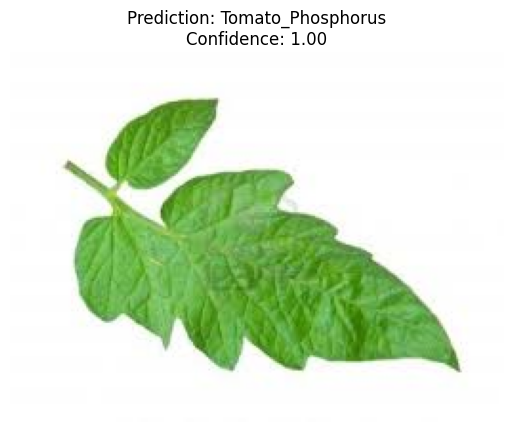


Processing image: images (1) (1).jpg
Prediction: Potato_Water_Stress
Confidence: 0.8511186242103577


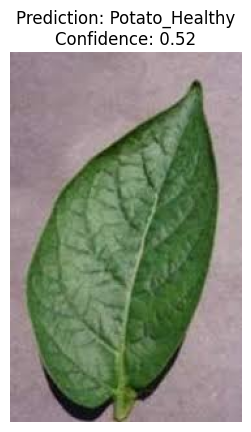

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

for filename in multi_uploaded_files.keys():
    print(f"\nProcessing image: {filename}")

    # The predict_image function already handles loading, resizing, normalizing, and predicting
    # It also includes an error check for image loading
    predict_image(filename)

    # Optionally, display the image with its prediction
    img_display = cv2.imread(filename)
    if img_display is not None:
        img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
        # Re-run prediction to get values for display title
        # This is a bit redundant but ensures the title has the correct info if `predict_image` printed only
        img_resized_for_display = cv2.resize(img_display, (224, 224))
        img_normalized_for_display = img_resized_for_display / 255.0
        img_input_for_display = np.expand_dims(img_normalized_for_display, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input_for_display)
        interpreter.invoke()
        output_for_display = interpreter.get_tensor(output_details[0]['index'])[0]
        pred_index_for_display = np.argmax(output_for_display)
        confidence_for_display = np.max(output_for_display)
        predicted_class_for_display = classes[pred_index_for_display]

        plt.title(f"Prediction: {predicted_class_for_display}\nConfidence: {confidence_for_display:.2f}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not display image {filename}.")

In [ ]:
from google.colab import files

print("Upload multiple images:")
multi_uploaded_files = files.upload()

Upload multiple images:


Saving download.jpg to download.jpg
Saving images.jpg to images (6).jpg



Processing image: download.jpg
Prediction: Potato_Nitrogen
Confidence: 0.4131208062171936


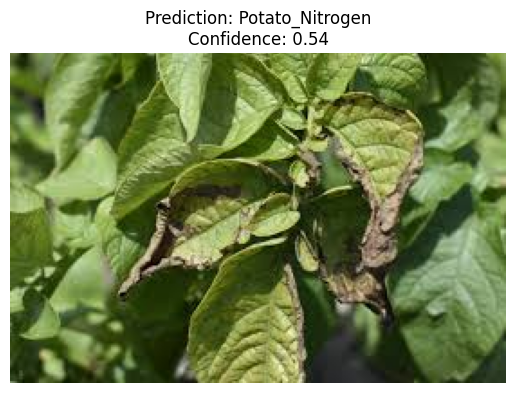


Processing image: images (6).jpg
Prediction: Tomato_Phosphorus
Confidence: 0.9747862815856934


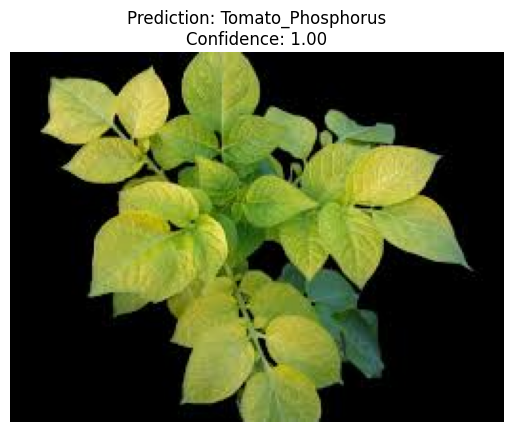

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

for filename in multi_uploaded_files.keys():
    print(f"\nProcessing image: {filename}")

    # The predict_image function already handles loading, resizing, normalizing, and predicting
    # It also includes an error check for image loading
    predict_image(filename)

    # Optionally, display the image with its prediction
    img_display = cv2.imread(filename)
    if img_display is not None:
        img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
        # Re-run prediction to get values for display title
        # This is a bit redundant but ensures the title has the correct info if `predict_image` printed only
        img_resized_for_display = cv2.resize(img_display, (224, 224))
        img_normalized_for_display = img_resized_for_display / 255.0
        img_input_for_display = np.expand_dims(img_normalized_for_display, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input_for_display)
        interpreter.invoke()
        output_for_display = interpreter.get_tensor(output_details[0]['index'])[0]
        pred_index_for_display = np.argmax(output_for_display)
        confidence_for_display = np.max(output_for_display)
        predicted_class_for_display = classes[pred_index_for_display]

        plt.title(f"Prediction: {predicted_class_for_display}\nConfidence: {confidence_for_display:.2f}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not display image {filename}.")

In [ ]:
from google.colab import files

print("Upload multiple images:")
multi_uploaded_files = files.upload()

Upload multiple images:


Saving look.jpg to look.jpg
Saving new.jpg to new.jpg
Saving ok.jpg to ok.jpg
Saving test.jpg to test.jpg


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

for filename in multi_uploaded_files.keys():
    print(f"\nProcessing image: {filename}")

    # The predict_image function already handles loading, resizing, normalizing, and predicting
    # It also includes an error check for image loading
    predict_image(filename)

    # Optionally, display the image with its prediction
    img_display = cv2.imread(filename)
    if img_display is not None:
        img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
        # Re-run prediction to get values for display title
        # This is a bit redundant but ensures the title has the correct info if `predict_image` printed only
        img_resized_for_display = cv2.resize(img_display, (224, 224))
        img_normalized_for_display = img_resized_for_display / 255.0
        img_input_for_display = np.expand_dims(img_normalized_for_display, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input_for_display)
        interpreter.invoke()
        output_for_display = interpreter.get_tensor(output_details[0]['index'])[0]
        pred_index_for_display = np.argmax(output_for_display)
        confidence_for_display = np.max(output_for_display)
        predicted_class_for_display = classes[pred_index_for_display]

        plt.title(f"Prediction: {predicted_class_for_display}\nConfidence: {confidence_for_display:.2f}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not display image {filename}.")


Processing image: look.jpg


NameError: name 'predict_image' is not defined

In [ ]:
from google.colab import files

print("Upload multiple images:")
multi_uploaded_files = files.upload()

Upload multiple images:


Saving download.jpg to download.jpg


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

for filename in multi_uploaded_files.keys():
    print(f"\nProcessing image: {filename}")

    # The predict_image function already handles loading, resizing, normalizing, and predicting
    # It also includes an error check for image loading
    predict_image(filename)

    # Optionally, display the image with its prediction
    img_display = cv2.imread(filename)
    if img_display is not None:
        img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
        # Re-run prediction to get values for display title
        # This is a bit redundant but ensures the title has the correct info if `predict_image` printed only
        img_resized_for_display = cv2.resize(img_display, (224, 224))
        img_normalized_for_display = img_resized_for_display / 255.0
        img_input_for_display = np.expand_dims(img_normalized_for_display, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input_for_display)
        interpreter.invoke()
        output_for_display = interpreter.get_tensor(output_details[0]['index'])[0]
        pred_index_for_display = np.argmax(output_for_display)
        confidence_for_display = np.max(output_for_display)
        predicted_class_for_display = classes[pred_index_for_display]

        plt.title(f"Prediction: {predicted_class_for_display}\nConfidence: {confidence_for_display:.2f}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not display image {filename}.")


Processing image: download.jpg


NameError: name 'predict_image' is not defined